### Surface

<xarray.Dataset> Size: 3GB
Dimensions:    (longitude: 1440, latitude: 721, time: 62)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * time       (time) datetime64[ns] 496B 2019-07-01 ... 2019-07-31T12:00:00
Data variables:
    u10        (time, latitude, longitude) float64 515MB ...
    v10        (time, latitude, longitude) float64 515MB ...
    t2m        (time, latitude, longitude) float64 515MB ...
    msl        (time, latitude, longitude) float64 515MB ...
    pm1        (time, latitude, longitude) float32 257MB ...
    pm2p5      (time, latitude, longitude) float32 257MB ...
    pm10       (time, latitude, longitude) float32 257MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2025-01-05 17:48:16 GMT by grib_to_netcdf-2.36.0: grib_to_n...


/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


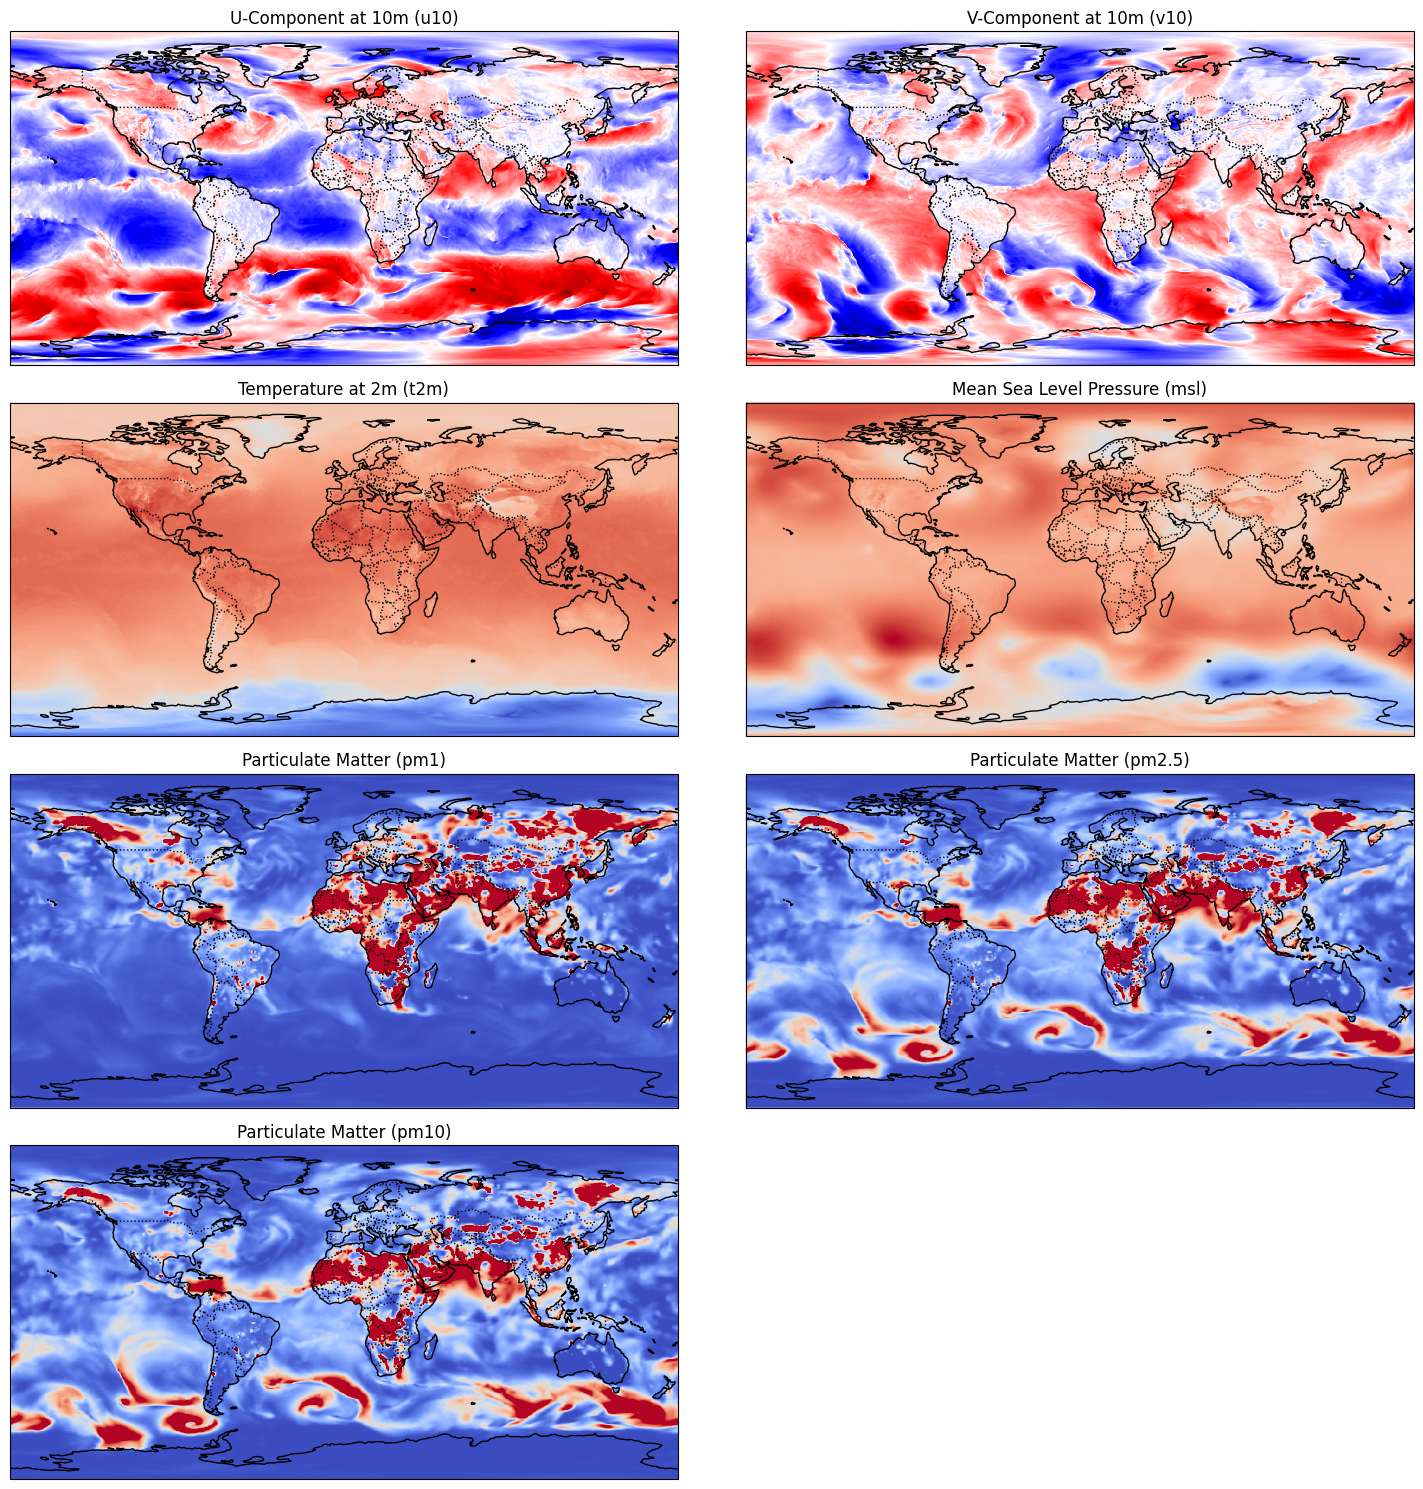

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
ds = xr.open_dataset('/l/users/fahad.khan/akhtar/Pangu/data/pangu_data/surface/surface_201907.nc')
print(ds)

# Extract the first time point
first_time = ds.isel(time=0)

# Set up the plotting figure with a 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the variables and their titles, along with color maps
variables = ['u10', 'v10', 't2m', 'msl', 'pm1', 'pm2p5', 'pm10']
titles = ['U-Component at 10m (u10)', 'V-Component at 10m (v10)', 'Temperature at 2m (t2m)', 'Mean Sea Level Pressure (msl)', 'Particulate Matter (pm1)', 'Particulate Matter (pm2.5)', 'Particulate Matter (pm10)']
colormaps = ['seismic', 'seismic', 'coolwarm', 'coolwarm', 'coolwarm', 'coolwarm', 'coolwarm']
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Loop over the variables and plot each one
for i, var in enumerate(variables):
    ax = axs[i // 2, i % 2]
    data = first_time[var]

    if var in pm_vars:
        # Compute the 5th and 95th percentiles
        vmin = float(data.quantile(0))
        vmax = float(data.quantile(0.95))
        im = data.plot(ax=ax, cmap=colormaps[i], vmin=vmin, vmax=vmax, add_colorbar=False)
    else:
        im = data.plot(ax=ax, cmap=colormaps[i], add_colorbar=False)

    ax.coastlines(resolution='110m', color='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='black')
    ax.set_title(titles[i])

# Remove the last empty subplot
fig.delaxes(axs[3, 1])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### Upper

<xarray.Dataset> Size: 25GB
Dimensions:    (longitude: 1440, latitude: 721, time: 744)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 6kB 2019-07-01 ... 2019-07-31T23:00:00
Data variables:
    u10        (time, latitude, longitude) float64 6GB ...
    v10        (time, latitude, longitude) float64 6GB ...
    t2m        (time, latitude, longitude) float64 6GB ...
    msl        (time, latitude, longitude) float64 6GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-09-04 09:21:10 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...


/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


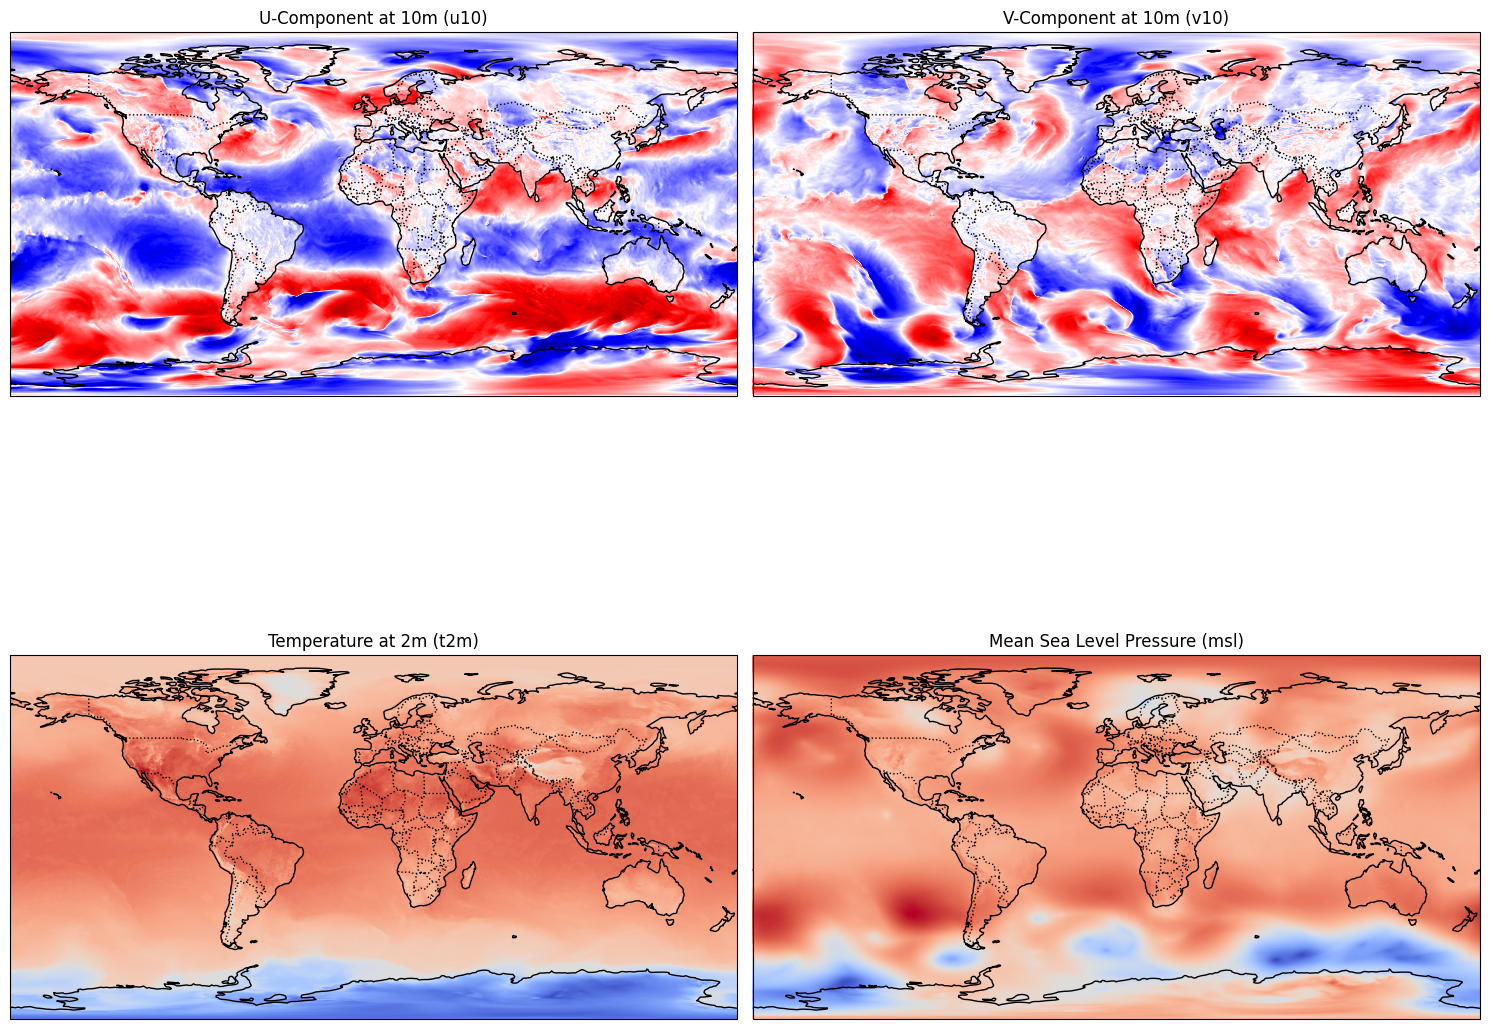

In [14]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
ds = xr.open_dataset('/l/users/fahad.khan/akhtar/Pangu/pangu-pytorch/data_analysis/surface_201907_origformat.nc')
print(ds)

# Extract the first time point
first_time = ds.isel(time=0)

# Set up the plotting figure with a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the variables and their titles, along with color maps
variables = ['u10', 'v10', 't2m', 'msl']
titles = ['U-Component at 10m (u10)', 'V-Component at 10m (v10)', 'Temperature at 2m (t2m)', 'Mean Sea Level Pressure (msl)']
colormaps = ['seismic', 'seismic', 'coolwarm', 'coolwarm']

# Loop over the variables and plot each one
for i, var in enumerate(variables):
    ax = axs[i // 2, i % 2]  # Adjust subplot position
    data = first_time[var]  # No need to slice level, as this is surface data
    
    # Plot the data with the specified colormap
    im = data.plot(ax=ax, cmap=colormaps[i], add_colorbar=False)

    # Add continent lines and labels
    ax.coastlines(resolution='110m', color='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='black')
    ax.set_title(titles[i])


# Removethe last empty subplot
# fig.delaxes(axs[2, 1])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()